# Cymatics plane → line geometry

Debug notebook for **cymatics-geometry**.

## What this pipeline does

1. **Grid** — place points on an **X × Y** lattice (up to **500 × 500**)
2. **Sources** — 8 emitters (corners + mid-edges). Always on; leave sliders at 0 to idle.
3. **Interference** — amp/λ add circular waves; Z is the sum
4. **Release** — radial XY shockwave (**0–150** world units, 1:1)
5. **Cloth** — neighbour springs; core stiff / edges flexible (**0–100**)
6. **Shape map** — same UV lattice + local offsets remapped onto **plane / cylinder / cone / frustum / variable cylinder / bead / custom 2D (SVG/DXF/DWG)**
7. **Crop / section box** — custom 2D is scaled uniformly (aspect kept) then cropped to the silhouette; an optional oriented cube clips the 3D result
8. **Lines** — reconnect as **parallel U and V grid lines** on the mapped surface
9. **Voxel print** — smooth-spline pipe lines into **PicoPie** OpenVDB solids and export **STL**

## Interactive UI (right panel)

1. **Display** (top) — `line color` (`difference` / `uniform white`) + X/Y line toggles
2. **Shape map** — target surface + params, or **custom 2D** upload (size keeps imported aspect ratio)
3. **Section box** — cube size / center / rotation that clips the mapped geometry
4. **Sources** — amp / λ / release (+ sync)
5. **Global** — time, decay, cloth, grid X/Y (max 500)
6. **Voxel print** — voxel size / pipe / smooth / strides + **Preview solid** / **Export STL**

Every slider has a **side number box** — click it and type for precise values.

After library changes, re-run the import cell so `src/` reloads. CLI: `uv run cymatics stl --help`.

All numeric wave sliders start at **0**.


In [32]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

for _name in list(sys.modules):
    if _name == "cymatics_geometry" or _name.startswith("cymatics_geometry."):
        del sys.modules[_name]

from cymatics_geometry.config import PipelineConfig
from cymatics_geometry.pipeline import export_line_obj, run_pipeline
from cymatics_geometry.visualization import (
    show_all_stages_matplotlib,
    show_interactive_line_viewer,
)
from cymatics_geometry.voxels import (
    VoxelPipeConfig,
    export_stl,
    pipe_and_export_stl,
    pipe_lines_to_voxels,
)

print("Ready.")


Ready.


## Static run — inspect every stage

Example with non-zero corner amps/λ so the stage overview is visible.
(The interactive viewer below starts everything at 0.)


Grid: 80×80 (X×Y), side=100.0
Active sources: ['SW', 'SE', 'NE', 'NW']
Amplitudes SW/SE/NE/NW/S/E/N/W: 1.000 / 0.850 / 0.550 / 0.900 / 0.000 / 0.000 / 0.000 / 0.000
frequency=1.000, time=0.000, decay=0.000
line_pattern=grid
Stage 1 — flat grid: 6400 points
Stage 2 — sources: ['SW', 'SE', 'NE', 'NW', 'S', 'E', 'N', 'W']
Stage 3 — interference field: z∈[-2.9193, 3.0956]
Stage 4 — displaced points: 6400 (xy released: 0)
Stage 4b — shape map: kind=plane
Stage 5 — line geometry: 12959 vertices, length=16282.830, cells=160 (pattern=grid, X=True, Y=True, stride=1, keepX=0, keepY=0)


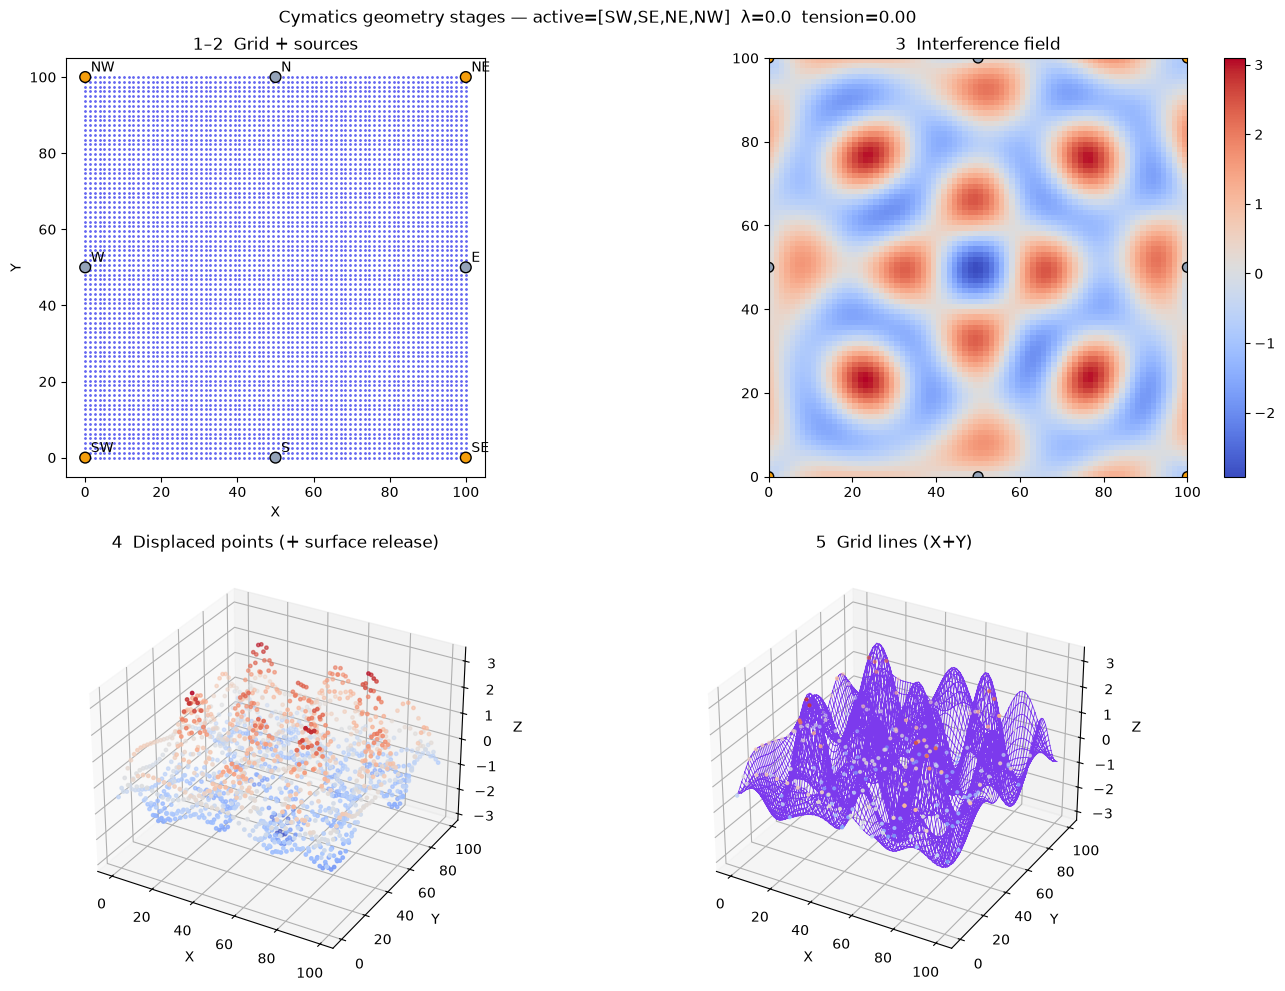

{'point_count': 6400,
 'grid_size': 80,
 'grid_size_x': 80,
 'grid_size_y': 80,
 'displacement_min': -2.9192802994419793,
 'displacement_max': 3.0955752964166283,
 'displacement_mean': -0.026620358637319742,
 'displacement_std': 1.0423844303842738,
 'border_released': 0,
 'xy_released': 0,
 'xy_offset_max': 0.0,
 'polyline_vertices': 12959,
 'polyline_length': 16282.830086799544,
 'amplitudes': [1.0, 0.85, 0.55, 0.9, 0.0, 0.0, 0.0, 0.0],
 'active': [True, True, True, True, False, False, False, False],
 'active_labels': ['SW', 'SE', 'NE', 'NW'],
 'wavelength': 0.0,
 'frequency': 1.0,
 'time': 0.0,
 'boundary_tension': 0.0,
 'cloth': 0.0,
 'release_pace': 0.0,
 'line_pattern': 'grid',
 'lines_x': True,
 'lines_y': True,
 'boundary_curve': True,
 'boundary_points': 316,
 'points_out_of_bounds': 0,
 'line_stride': 1,
 'boundary_lines_x': 0,
 'boundary_lines_y': 0,
 'shape': 'plane',
 'custom_shape_path': '',
 'custom_shape_size': 100.0,
 'section_box_enabled': False,
 'points_kept': 6400}

In [33]:
config = PipelineConfig(
    grid_size_x=80,
    grid_size_y=80,
    side_length=100.0,
    amplitude_sw=1.0,
    amplitude_se=0.85,
    amplitude_ne=0.55,
    amplitude_nw=0.9,
    wavelength_sw=25.0,
    wavelength_se=25.0,
    wavelength_ne=25.0,
    wavelength_nw=25.0,
    release_sw=0.0,
    release_se=0.0,
    release_ne=0.0,
    release_nw=0.0,
    active_s=False,
    active_e=False,
    active_n=False,
    active_w=False,
    time=0.0,
    decay=0.0,
    line_pattern="grid",
    lines_x=True,
    lines_y=True,
)

result = run_pipeline(config, verbose=True)
show_all_stages_matplotlib(result)
result.stats


## Interactive 3D grid lines

**View left · scrollable controls right.**

**Display** (top): **Saved configs** (dropdown + Load) · X/Y toggles · **boundary** (closed polyline of the original 2D outline — plane rectangle or imported silhouette — with the same point order after the waves) · **line step** · **keep X / keep Y**. Grid size, line step, and keep X/Y are stored in saved configs.

**Sources**: amplitude can be **negative** (flips wave direction).

**Shape map** includes **bead** (sphere diameter + independent top/bottom slice radii) and **custom 2D** (upload SVG/DXF/DWG; size slider keeps the imported aspect ratio and crops the square to the silhouette).

**Section box** (under Shape map): enable the cube, then set size XYZ, center XYZ, and rotation XYZ. **Fit box** sizes it to the current geometry.


In [34]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

for _name in list(sys.modules):
    if _name == "cymatics_geometry" or _name.startswith("cymatics_geometry."):
        del sys.modules[_name]

from cymatics_geometry.config import PipelineConfig
from cymatics_geometry.visualization import show_interactive_line_viewer

# Re-run the import cell above first so src/ reloads, then this cell.
# Display (top right, under X/Y): line step + keep X/Y — status shows cell count.
# step=3 keeps every 3rd line; keep=0 means "use step". Set keep=1 to drop the
# middle and leave only the first+last line on that axis.
show_interactive_line_viewer(
    PipelineConfig(
        grid_size_x=60,
        grid_size_y=60,
        line_stride=3,
        boundary_lines_x=0,
        boundary_lines_y=0,
    ),
    amplitude_max=10.0,
)


    'data': [{'hoverinfo': 'skip',
              'line': {'color': '#64748b', 'd…

## Export line geometry

Writes the current `result` line mesh to `exports/` as an OBJ.


In [4]:
if "result" not in globals():
    result = run_pipeline(
        PipelineConfig(grid_size_x=60, grid_size_y=60),
        verbose=False,
    )

export_dir = ROOT / "exports"
path = export_line_obj(result, export_dir)
print("Wrote", path)


Wrote C:\Users\liv\sources\cymatics-geometry\exports\cymatics_line_20260728_005018.obj


## Voxel pipe → printable STL

Pipes the current `result` lines with **PicoPie** voxels (OpenVDB). Lines are cubic-spline smoothed first (`spine_smooth`). Tune:

| Slider / field | Practical effect |
|---|---|
| `voxel_size` | Smaller = smoother surface + denser preview rings / spines |
| `pipe_radius` | Outer tube thickness along each line |
| `inner_radius` | Hollow bore (`0` = solid rod) |
| `modulation_*` | Surface ripples along / around the pipe |
| `line_stride` / `point_stride` | Thin the lattice for speed |
| `boundary_lines` (`keep X` / `keep Y`) | `+N` keep only first/last N (drops the middle); `−N` shave ends; `0` = line step only |
| `spine_samples` / `spine_smooth` | Spline density + kink rounding on lines |

In the interactive viewer **Voxel print** panel:

- **Preview solid** — lofted cyan tubes (voxel size affects facet density; moving voxel sliders refreshes the overlay)
- **Export STL** — real PicoPie voxels + writes `exports/cymatics_pipe_*.stl`

Re-run the import cell, then the interactive viewer cell, after pulling these fixes. This cell is the headless library API (also `uv run cymatics stl`).


In [ ]:
if "result" not in globals():
    result = run_pipeline(
        PipelineConfig(
            grid_size_x=40,
            grid_size_y=40,
            amplitude_sw=1.0,
            amplitude_se=0.85,
            amplitude_ne=0.55,
            amplitude_nw=0.9,
            wavelength_sw=25.0,
            wavelength_se=25.0,
            wavelength_ne=25.0,
            wavelength_nw=25.0,
            shape="plane",
            lines_x=True,
            lines_y=True,
        ),
        verbose=False,
    )

vcfg = VoxelPipeConfig(
    voxel_size=0.8,
    pipe_radius=1.2,
    inner_radius=0.0,
    modulation_amp=0.2,
    modulation_freq=3.0,
    modulation_lobes=6,
    line_stride=3,
    point_stride=2,
    spine_samples=40,
    spine_smooth=1.5,
)
solid, stl_path = pipe_and_export_stl(result, ROOT / "exports", vcfg, verbose=True)
print("STL", stl_path)
print("faces", solid.stats["faces"], "volume", round(solid.volume, 2), "watertight", solid.is_watertight)
